In [1]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_rw, simulate_network_gp

0.19867200000000004


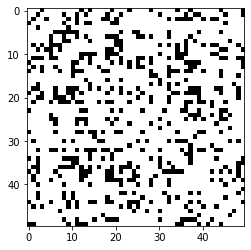

In [9]:
Y, X, probas_true = simulate_network_gp(
    n_nodes=50, n_time_steps=50, density=0.2, random_state=4)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

0.09913600000000003


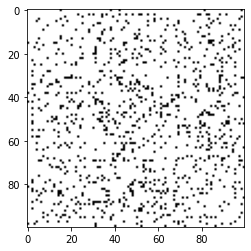

In [18]:
Y, X, probas_true = simulate_network_rw(
    n_nodes=100, n_time_steps=25, density=0.1, random_state=12)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

In [125]:
from sklearn.metrics import euclidean_distances
from sklearn.utils import check_random_state
import scipy.sparse as sp

def gp_network(n_nodes=100, n_time_steps=100, n_features=2, sparse=True, density=0.2, random_state=42):
    rng = check_random_state(random_state)
    ts = np.arange(n_time_steps)
    dist_sq = euclidean_distances(ts[:, None], squared=True)
    ls = (4./n_time_steps) ** 2
    C = np.exp(-0.5 * dist_sq * ls )
    X = rng.multivariate_normal(np.zeros_like(ts), cov=C, size=(n_nodes, n_features)).transpose((2, 0, 1))
                
    
    means = []
    subdiag = np.tril_indices(n_nodes, k=-1)
    for t in range(n_time_steps):
        means.append((X[t] @ X[t].T)[subdiag])
  
    Ys = []    
    for t in range(n_time_steps):
        Y = np.zeros((n_nodes, n_nodes))

        X[t] *= np.sqrt(density) 
        sigma_sq = 0.5
        y = means[t] + np.sqrt(sigma_sq) * rng.randn(*means[t].shape)
        #print(np.sqrt((means[t] ** 2).mean() / sigma_sq))
        
        zif_mask = rng.binomial(1, density * np.ones_like(y))
        y = zif_mask * y
        
        print(np.sqrt((zif_mask * means[t] ** 2).mean() / sigma_sq))
        
    

        Y[subdiag] = y
        Y += Y.T
        
        Y = sp.csr_array(Y, dtype=float) if sparse else Y.astype(float)
        Ys.append(Y)

    Y = Ys if sparse else np.dstack(Ys).transpose((2, 0, 1))
    
    return Y, X, np.stack(means)
    

In [126]:
Y[0].nnz / np.prod(Y[0].shape)

0.2592

0.8527875810344923
0.9161459534708658
0.8938135497705442
0.9492662568139936
0.8220335523989922
0.7994669561363791
0.9193707391903126
0.8787739468258193
0.9680245226798553
0.9238124879391422
0.9473678366366967
0.9471763792429676
0.9653504341500199
0.9994122471665362
0.9503105870687958
1.0050647966644835
0.9721266866044316
1.0195974522650595
0.9791447772675229
0.9620618541281961
1.0403395316861754
1.0068373536417343
0.8839048595666534
0.9663850938066822
1.088979083570997
1.0623821203525605
1.0142889722051456
0.9508944698232952
0.9922301628654143
0.9746953653924646
1.0133490367624507
1.1511663649925568
0.9988002305706846
1.0386126693662194
1.047997466567664
1.053066981526182
1.0763836661642634
1.1574697544411396
1.0428382324254446
1.0013946868956458
1.1593781193622603
1.091929652317597
1.1399599244517227
1.0515136053476273
0.8645254082896625
1.0031948846046668
1.0308007413519127
0.9130953764624817
1.052397729716938
0.9968368836641164
1.053818781436502
0.9982984712484111
0.9565006403187033

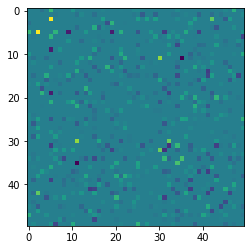

In [127]:
Y, X, means = gp_network(n_nodes=50, n_time_steps=100, sparse=True, density=0.25)

print(np.mean([Yt.mean() for Yt in Y]))
plt.imshow(Y[-1].toarray(), cmap='viridis_r')

In [10]:
import os

out_dir = f'fase_data/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

np.savetxt(os.path.join(out_dir, 'time_points.npy'), np.linspace(0, 1, len(Y)))
for t in range(len(Y)):
    np.savetxt(os.path.join(out_dir, f'Y_{t+1}.npy'), Y[t].toarray())
    np.savetxt(os.path.join(out_dir, f'X_{t+1}.npy'), X[t])

In [11]:
! Rscript fase.R

Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var


── Column specification ────────────────────────────────────────────────────────
cols(
  X1 = col_double()
)

[1] "q = 4 ngcv = -0.971025500930546"
[1] "q = 6 ngcv = -0.97066234338502"
[1] "q = 8 ngcv = -0.969287171317474"
[1] "q = 10 ngcv = -0.967824546071528"
[1] "q = 12 ngcv = -0.966521123142868"
[1] "q = 14 ngcv = -0.965045068577213"
[1] "q = 16 ngcv = -0.963681997901209"
[1] 0.004045273


In [12]:
rdpg = DynamicRDPG(n_features=2, rw_order=2)
rdpg.sample(Y, n_burnin=200, n_samples=200)

100%|████████████████████████████████████████████████████████████████████████████| 400/400 [00:30<00:00, 13.02it/s]


In [13]:
from scipy.linalg import orthogonal_procrustes

X_pred = rdpg.X_.copy()
for t in range(len(Y)):
    R, _ = orthogonal_procrustes(X_pred[t], X[t])
    X_pred[t] = X_pred[t] @ R
    
#print(rdpg.auc_)
np.mean((X_pred - X) ** 2)

0.003391238586377826